# **Homework 6: Pretrained Models and Explainability**

Was expected to be run in Google Colab. I ran this on my M4 Macbook Air. 

In [140]:
# Pytorch, our automatic differentiation library
import torch

# Torchvision, contains pretrained neural networks for images
from torchvision.models import resnet18, ResNet18_Weights

# for making custom transformations
from torchvision import transforms

# Python Imaging Library, contains some image manipulation functionality
from PIL import Image

import matplotlib.pyplot as plt

## **Tutorial (Not included in report)**
Upload an image named to the Colab server by clicking the folder on the left and then the upload icon. We'll turn it into a suitable input for a pre-trained Resnet (residual network) architecture.

The pretrained neural network expects images to undergo a specific set of transformations (stored in `t` below): in particular images must be reshaped, cropped, and normalized. However, `matplotlib` expects things slightly differently:

- `matplotlib` expects images to be in $[0,1]$, not normalized to be 0-mean.
- `matplotlib` expects images of height $H$ and width $W$ to be $H \times W \times 3$ while the ResNet expects images to be $B \times 3 \times H \times W$ (with batch size $B$, even if the batch size is 1). The 3 represents the color channels: the red, green, and blue images.

These details aren't too important, but you should understand that, because `matplotlib` and the ResNet expect their inputs in different forms, you need to run the `process_for_xx` functions before calling either.

In [141]:
t = ResNet18_Weights.IMAGENET1K_V1.transforms()

image_to_tensor = transforms.Compose([
    transforms.Resize(t.resize_size, interpolation=t.interpolation),
    transforms.CenterCrop(t.crop_size),
    transforms.ToTensor(),
])

process_for_nn = transforms.Compose([
    transforms.Normalize(mean=t.mean, std=t.std),
    transforms.Lambda(lambda x: x.unsqueeze(0)),
])

process_for_imshow = lambda x: x.permute(1,2,0)

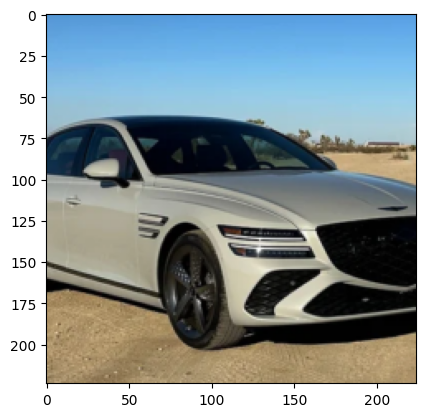

In [142]:
img = Image.open('car.jpg') # change filename to match your uploaded file

x = image_to_tensor(img)

plt.imshow(process_for_imshow(x))

The code below loads the pre-trained model and prints out all of its layers. You should see a lot of 2d convolution layers, a lot of ReLU layers, a lot of batch norm layers (which we haven't talked about) and some pooling layers.

In [143]:
nn = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
nn.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

If you want to look at the parameters, you can do soo via `nn.parameters()` or `nn.named_parameters()` which loads the parameter names as well.

In [144]:
for name, param in nn.named_parameters():
    print(f"{name:<30} {param.shape}")

conv1.weight                   torch.Size([64, 3, 7, 7])
bn1.weight                     torch.Size([64])
bn1.bias                       torch.Size([64])
layer1.0.conv1.weight          torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight            torch.Size([64])
layer1.0.bn1.bias              torch.Size([64])
layer1.0.conv2.weight          torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight            torch.Size([64])
layer1.0.bn2.bias              torch.Size([64])
layer1.1.conv1.weight          torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight            torch.Size([64])
layer1.1.bn1.bias              torch.Size([64])
layer1.1.conv2.weight          torch.Size([64, 64, 3, 3])
layer1.1.bn2.weight            torch.Size([64])
layer1.1.bn2.bias              torch.Size([64])
layer2.0.conv1.weight          torch.Size([128, 64, 3, 3])
layer2.0.bn1.weight            torch.Size([128])
layer2.0.bn1.bias              torch.Size([128])
layer2.0.conv2.weight          torch.Size([128, 128, 3, 3])
layer2.0.bn2.w

Here's some code to compute the total number of parameters!

In [145]:
sum([torch.numel(param) for param in list(nn.parameters())])

11689512

That's a lot of parameters! Almost 12 million, and that's for one of the smallest pretrained architectures we could find.

Now let's run it on our example image

In [146]:
out = nn(process_for_nn(x))
out.shape # because our batch size is 1, we get 1 row of 1000=#Classes

torch.Size([1, 1000])

The first question you might ask: are the values outputted here probabilities, or are they the real-valued scores before the softmax is applied? There's one way to check: does the vector above sum to 1? If yes, they're probabilities, if no, they're scores.

(A heuristic you can also check: are any values negative? If yes, then these are definitely scores)

In [147]:
print("Sum:", torch.sum(out))
print("Negatives:", (out < 0).any())

Sum: tensor(0.0258, grad_fn=<SumBackward0>)
Negatives: tensor(True)


Next question: what does each component correspond to?

The 1000 classes here are the ImageNet classes. To figure out which index corresponds to which class, we can download the array.

In [148]:
import urllib.request, json

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

print(len(classes))  # 1000
print(classes[:10])


1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


I've written a helper function to aid you in understanding the model's output

In [149]:
def print_class_probs(out_vector, top_C = 10):
  inds = torch.argsort(out_vector, descending=True)[:top_C] # take top_C outputs

  probs = torch.softmax(out_vector, dim=0)

  for i in inds:
    print(f"Class: {classes[i]:<20}    P(Y=y|image): {probs[i]}")


In [150]:
print_class_probs(out[0])

Class: grille                  P(Y=y|image): 0.3819168508052826
Class: sports car              P(Y=y|image): 0.25658491253852844
Class: beach wagon             P(Y=y|image): 0.132165789604187
Class: car wheel               P(Y=y|image): 0.12622550129890442
Class: racer                   P(Y=y|image): 0.03587186336517334
Class: convertible             P(Y=y|image): 0.028253009542822838
Class: minivan                 P(Y=y|image): 0.021705759689211845
Class: limousine               P(Y=y|image): 0.01061357744038105
Class: pickup                  P(Y=y|image): 0.003886828664690256
Class: cab                     P(Y=y|image): 0.0011507777962833643


Sweet! Play around with a few images on this model and see what you find.

### GPU Acceleration

Finally, let's take a look at how much faster our code can be when we run it on GPUs instead of CPUs. When you run the cell below, I expect the result to be

`[CpuDevice(id=0)]`

Indicating that the only device you have available for computation is a Google CPU.

In [151]:
torch.cuda.is_available()

False

How long does it take to perform the forward pass for a single image? The line below will perform the forward pass multiple times, then compute the average (and standard deviation) of those runtimes

In [152]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

nn = nn.to(device)
x = x.to(device)

In [153]:
nn_input = process_for_nn(x)

%timeit out = nn(nn_input)


7.64 ms ± 327 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


At the time of testing this, I am seeing a ~30-fold speedup for running on the GPU instead of on the CPU.

# **Problem 1**

Little scaffolding is provided for the tasks in this assignment. The autodiff lab is particularly helpful for this assignment.

Instructions are provided in the assignment, including tips if your code is running slow or running out of memory. If you want to track memory usage, click the triangle in the top right of the Colab session, and then "View Resources".

Ocassionally, students have run into a strange issue where cuda reported as being available but there was an issue connecting to the GPU. To help check that a GPU is available, you can run the following code:

In [154]:
def get_prob(out_vector, class_idx):
  probs = torch.softmax(out_vector, dim=0)
  return probs[class_idx]


In [155]:
# activation maximization

# raw image x of a car to a goldfish
my_image = x.clone().detach().requires_grad_(True) # copy image, set requires grad to true
GOLDFISH_IDX = 1
step_size = 0.001

n_iters = 1000

# track per-iteration history
history = dict(
    iter=[],
    s=[],
    grad=[],
    probs=[]
)

for iter_id in range(n_iters):
    res = nn(process_for_nn(my_image))

    prob_goldfish = get_prob(res[0], GOLDFISH_IDX).item()
    
    res[0][GOLDFISH_IDX].backward()

    history['iter'].append(iter_id)
    history['s'].append(res[0][GOLDFISH_IDX].item())
    history['grad'].append(my_image.grad)
    history['probs'].append(prob_goldfish)

    if prob_goldfish > 0.9999999:
        print("Stopped prematurely at interation", iter_id)
        break

    if iter_id < n_iters - 1: # skip update the last time
        my_image.data = my_image.data + step_size * my_image.grad 

    my_image.grad = None


res = nn(process_for_nn(my_image))
print(get_prob(res[0], GOLDFISH_IDX))

Stopped prematurely at interation 261
tensor(1., grad_fn=<SelectBackward0>)


In [156]:
print_class_probs(res[0])

Class: goldfish                P(Y=y|image): 1.0
Class: axolotl                 P(Y=y|image): 5.7610478165770473e-08
Class: crayfish                P(Y=y|image): 9.549501467365218e-11
Class: tench                   P(Y=y|image): 8.999889722360876e-11
Class: barracouta              P(Y=y|image): 4.364831412972947e-11
Class: coho                    P(Y=y|image): 3.384092658875737e-11
Class: eft                     P(Y=y|image): 2.4726318215151366e-11
Class: ambulance               P(Y=y|image): 1.2859519872565617e-11
Class: gar                     P(Y=y|image): 8.414086268004883e-12
Class: puffer                  P(Y=y|image): 6.815182532898811e-12


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.038081173..0.9880719].


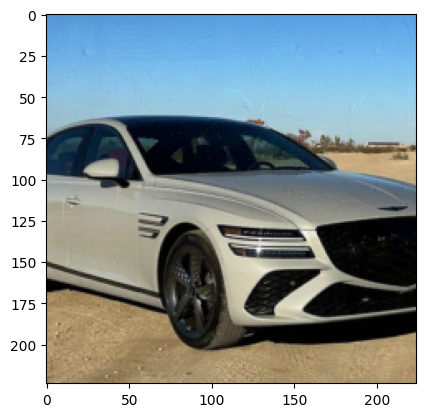

In [157]:
my_image_detached = my_image.detach()
plt.imshow(process_for_imshow(my_image_detached))

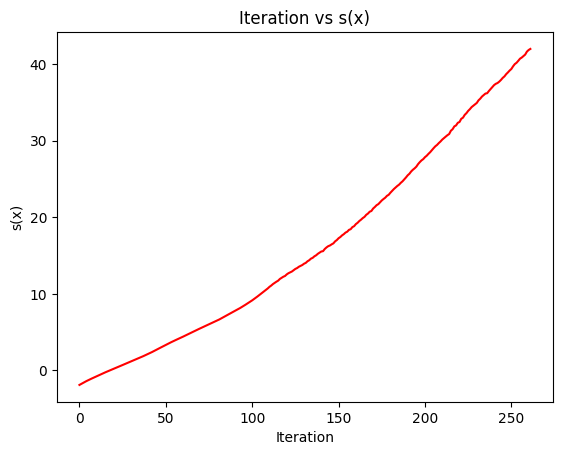

In [158]:
plt.plot(history['iter'], history['s'], 'r', label='s(x)')
plt.xlabel('Iteration')
plt.ylabel('s(x)')
plt.title('Iteration vs s(x)')
plt.show()

#### Fixing Error Message
Reparameterizing: making an valid image

In [159]:
my_image2 = x.clone().detach()

# logit function returns pos/neg inf if any pixels are exactly 0 or 1
has_zero = (my_image2 == 0).any()
has_one = (my_image2 == 1).any()
if has_zero or has_one:
    print("Clamping image")
    my_image2 = torch.clamp(my_image2, min=0.001, max=0.999)

Clamping image


In [160]:
# initialize x' = \sigma^{-1}(x)
x_prime = torch.logit(my_image2).requires_grad_(True)

In [161]:
# activation maximization once more

step_size = 0.01
n_iters = 1000

# track per-iteration history
history2 = dict(
    iter=[],
    s=[],
    grad=[],
    probs=[]
)

for iter_id in range(n_iters):
    res = nn(process_for_nn(torch.sigmoid(x_prime)))

    prob_goldfish = get_prob(res[0], GOLDFISH_IDX).item()
    
    res[0][GOLDFISH_IDX].backward()

    history2['iter'].append(iter_id)
    history2['s'].append(res[0][GOLDFISH_IDX].item())
    history2['grad'].append(x_prime.grad)
    history2['probs'].append(prob_goldfish)

    if prob_goldfish > 0.9999999:
        print("Stopped prematurely at interation", iter_id)
        break

    if iter_id < n_iters - 1: # skip update the last time
        x_prime.data = x_prime.data + step_size * x_prime.grad 

    x_prime.grad = None


res2 = nn(process_for_nn(torch.sigmoid(x_prime)))
print(get_prob(res2[0], GOLDFISH_IDX))

Stopped prematurely at interation 827
tensor(1., grad_fn=<SelectBackward0>)


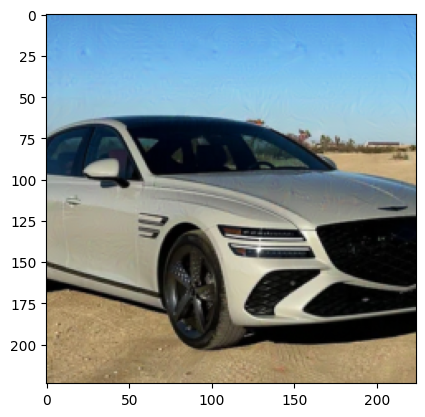

In [162]:
x_prime_detached = x_prime.detach()
plt.imshow(process_for_imshow(torch.sigmoid(x_prime_detached)))

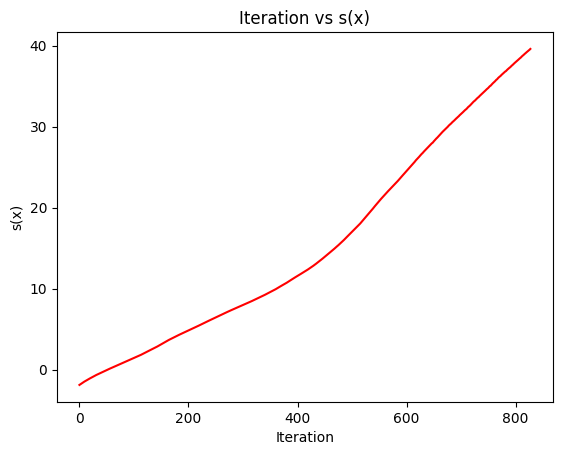

In [163]:
plt.plot(history2['iter'], history2['s'], 'r', label='s(x)')
plt.xlabel('Iteration')
plt.ylabel('s(x)')
plt.title('Iteration vs s(x)')
plt.show()

#### Something similar to my image

In [164]:
SPORTS_CAR_IDX = 817

my_image3 = x.clone().detach()

# logit function returns pos/neg inf if any pixels are exactly 0 or 1
has_zero = (my_image3 == 0).any()
has_one = (my_image3 == 1).any()
if has_zero or has_one:
    print("Clamping image")
    my_image3 = torch.clamp(my_image3, min=0.001, max=0.999)

# initialize x' = \sigma^{-1}(x)
x_prime2 = torch.logit(my_image3).requires_grad_(True)

Clamping image


In [165]:
# activation maximization once more

step_size = 0.01
n_iters = 1000

# track per-iteration history
history3 = dict(
    iter=[],
    s=[],
    grad=[],
    probs=[]
)

for iter_id in range(n_iters):
    res = nn(process_for_nn(torch.sigmoid(x_prime2)))

    prob_sportscar = get_prob(res[0], SPORTS_CAR_IDX).item()
    
    res[0][SPORTS_CAR_IDX].backward()

    history3['iter'].append(iter_id)
    history3['s'].append(res[0][SPORTS_CAR_IDX].item())
    history3['grad'].append(x_prime2.grad)
    history3['probs'].append(prob_sportscar)

    if prob_sportscar > 0.9:
        print("Stopped prematurely at interation", iter_id)
        break

    if iter_id < n_iters - 1: # skip update the last time
        x_prime2.data = x_prime2.data + step_size * x_prime2.grad 

    x_prime2.grad = None


res3 = nn(process_for_nn(torch.sigmoid(x_prime2)))
print(get_prob(res3[0], SPORTS_CAR_IDX))

Stopped prematurely at interation 58
tensor(0.9022, grad_fn=<SelectBackward0>)


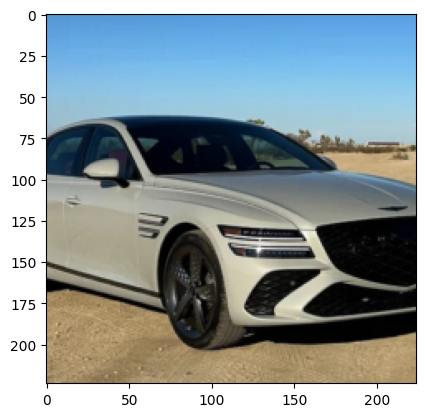

In [166]:
x_prime2_detached = x_prime2.detach()
plt.imshow(process_for_imshow(torch.sigmoid(x_prime2_detached)))

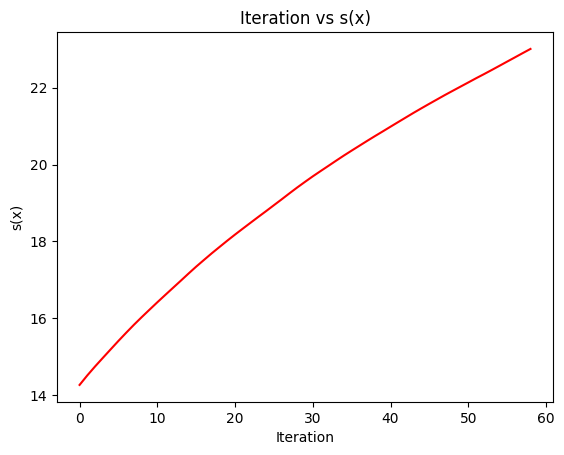

In [167]:
plt.plot(history3['iter'], history3['s'], 'r', label='s(x)')
plt.xlabel('Iteration')
plt.ylabel('s(x)')
plt.title('Iteration vs s(x)')
plt.show()

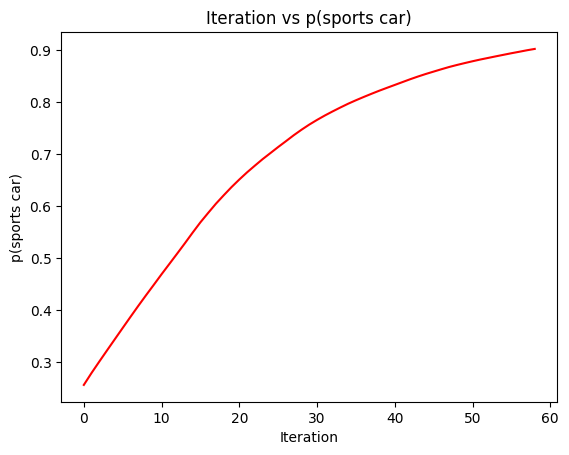

In [168]:
plt.plot(history3['iter'], history3['probs'], 'r', label='probs')
plt.xlabel('Iteration')
plt.ylabel('p(sports car)')
plt.title('Iteration vs p(sports car)')
plt.show()

# **Problem 2**: Lime

The code below is (virtually) all you need to play with the feature attribution library `lime`.

In [169]:
%pip install lime


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


`lime` assumes a numpy array as input and output, and (like matplotlib) assumes that the channel (R,G,B) axis is the last one. So we've provided another transformation which turns a numpy array that lime expects into a torch tensor that the neural network expects.

In [170]:
import numpy as np
x_np = process_for_imshow(x).to('cpu').numpy()
nn = nn.to('cpu')

# lime assumes both input and output are numpy arrays
np_to_nn_input = transforms.Compose([
    transforms.Lambda(lambda x: torch.tensor(x, dtype=torch.float32).permute(0,3,1,2)),
    transforms.Normalize(mean=t.mean, std=t.std)
])

In [171]:
from lime import lime_image

def predict_fn(x_np):
    logits = nn(np_to_nn_input(x_np))
    probs = torch.softmax(logits, dim=-1)
    return np.array(probs.detach()) # convert back to numpy

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image=np.array(x_np), # expects an image as input, not a batch
    classifier_fn=predict_fn,
    top_labels=5, # how many classes to build explanations for. Takes the ones with highest probabilities.
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/7w/sxl8r5055m96qpdzv4ckg9b40000gn/T/ipykernel_75675/3272316759.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(probs.detach()) # convert back to numpy
100%|██████████| 1000/1000 [00:07<00:00, 135.37it/s]


Class: sports car


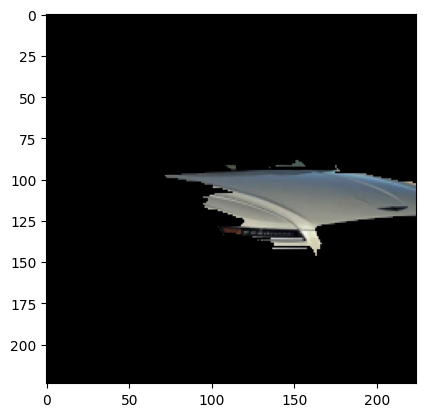

In [172]:
# vary this index to check the 5 classes that explanations were built for
label = explanation.top_labels[1] # sports car in this case

# Lime sorts the image into regions and ranks them on how influential they are
# to the final prediction. num_features below controls how many regions
# are shown to you. Vary it to understand the relative importance of patches.
masked_image, _ = explanation.get_image_and_mask(
    label,
    positive_only=True,
    num_features=1,
    hide_rest=True
)

print(f"Class: {classes[label]}")
plt.imshow(masked_image)